In [23]:
EXP_NAME="4MAY"
N = 20000
n_test = 1000
n_train = 800
seed = 4
minority_perc = 0.4
# prevalence = 0.10

In [24]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [25]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm, gamma, beta, truncnorm
from scipy.special import expit
from scipy.optimize import bisect
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import class_balanced_sampling, proportion_preserving_sampling, scale_dataset, plot_cat_feature, plot_cont_feature, apply_treatment_bias

np.random.seed(seed)

# Generate the clinical ground truth 

## Latent health and outcome

In [26]:
def generate_latent_health(n_pop, S):
  """ 
  Generates the latent health state of the population, underlying cause of the outcome
  """

  # Health Latent driving both clinical manifestion and target outcome
  health_latent = gamma.rvs(a=2, scale=1.5, size=n_pop)

  # Udesc, latent independent of the sensitive attribute
  u_desc = health_latent + gamma.rvs(a=2.1, scale=1, size=n_pop)

  # Ucorr, latent influenced by S
  u_corr = health_latent + np.where(S == 0, 0.3, 1.7) * gamma.rvs(a=1.2, scale=1.0, size=n_pop)

  return health_latent, u_corr, u_desc

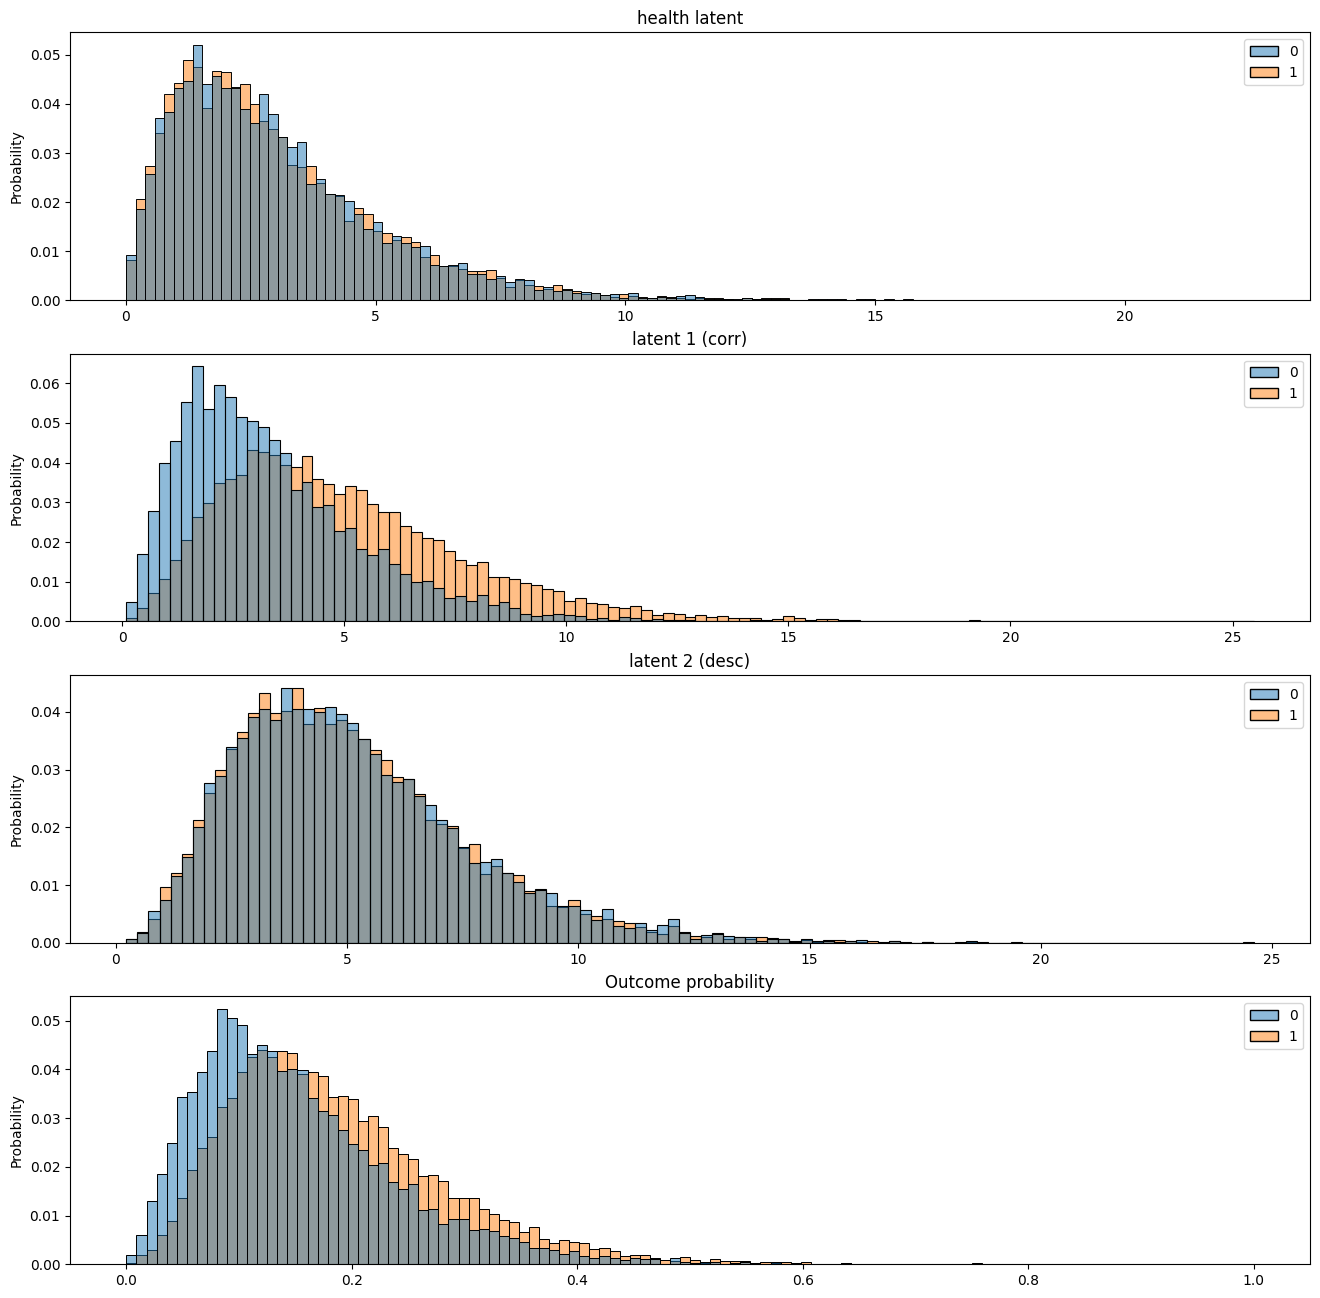

In [27]:
S = np.random.binomial(1, 1 - minority_perc, N)

health_latent, latent_corr, latent_desc = generate_latent_health(N, S)

Y_prob_raw = 2*latent_corr*latent_desc / (latent_corr + latent_desc) 
Y_prob = (Y_prob_raw - Y_prob_raw.min()) / (Y_prob_raw.max() - Y_prob_raw.min())

fig, axes = plt.subplots(4, 1, figsize=(16, 16))
sns.histplot(x=health_latent, common_norm=False, stat="probability", hue=S, ax=axes[0])
sns.histplot(x=latent_corr, common_norm=False, hue=S, stat="probability", ax=axes[1])
sns.histplot(x=latent_desc, common_norm=False, hue=S, stat="probability", ax=axes[2])
sns.histplot(x=Y_prob, common_norm=False, hue=S, stat="probability", ax=axes[3])
axes[0].set_title("health latent")
axes[1].set_title("latent 1 (corr)")
axes[2].set_title("latent 2 (desc)")
axes[3].set_title("Outcome probability")
plt.show()

Outcome prevalence: 10.17%


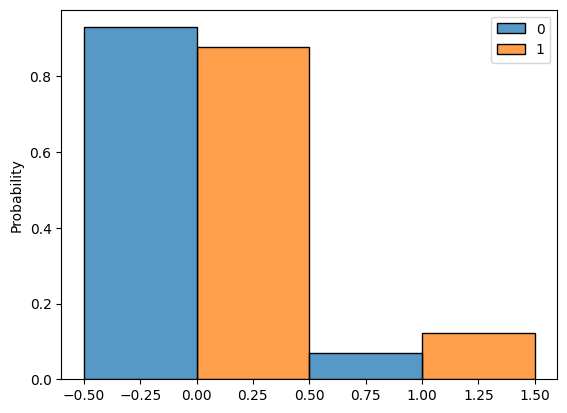

In [28]:
Y = (Y_prob > 0.3).astype(int)

prevalence = round(Y.sum() / len(Y) * 100, 2)
print(f"Outcome prevalence: {prevalence}%")

sns.histplot(x=Y, hue=S, common_norm=False, multiple='dodge', discrete=True, stat='probability')
plt.show()

## Clinical features

In [29]:
def generate_clinical_ground_truth(n_pop, S, latent_corr, latent_desc):

  # Biomarker 1: different means per S group
  biomarker_1 = 40 + 15*S + 5*latent_corr + np.random.normal(0, 10, n_pop)

  # Biomarker 2: independent of S 
  biomarker_2 = np.random.normal(100 + 8 * latent_desc, 15, n_pop)

  return pd.DataFrame({
    'S': S,
    'biomarker_1' : biomarker_1,
    'biomarker_2' : biomarker_2
  })

unbiased_pop = generate_clinical_ground_truth(N, S, latent_corr, latent_desc)
unbiased_pop['Y'] = Y

import os
data_dir = f"{PROJECT_ROOT}/data/synth/{EXP_NAME}"
os.makedirs(data_dir, exist_ok=True)

unbiased_pop.to_csv(f'{data_dir}/simple_unbiased_raw.csv', index=False)


In [30]:
from tableone import TableOne

# Descriptive statistics
table1 = TableOne(unbiased_pop,
                  groupby='S',
                  continuous=['biomarker_1','biomarker_2'],
                  categorical=['Y'],
                  missing=False,
                  sort=True
                  )

print("Population statistical summary")
print("="*80)
print(table1)

Population statistical summary
                          Grouped by S                            
                               Overall             0             1
n                                20000          8019         11981
biomarker_1, mean (SD)     70.8 (19.8)   57.0 (14.7)   80.0 (17.3)
biomarker_2, mean (SD)    140.6 (25.4)  140.7 (25.4)  140.5 (25.3)
Y, n (%)               0  17966 (89.8)   7456 (93.0)  10510 (87.7)
                       1   2034 (10.2)     563 (7.0)   1471 (12.3)



# Unbiased dataset

## Sampling

In [31]:
# --- Unbiased sampling ---
# Preserving the population initial demographics
unbiased_train, unbiased_test = proportion_preserving_sampling(
  unbiased_pop, 
  ['S', 'Y'], 
  n_train, n_test, seed)

# --- Class-balanced sampling ---
unbiased_bal_train, unbiased_bal_test = class_balanced_sampling(
  unbiased_pop, 
  "Y",
  "S",
  n_train, n_test, seed)

In [32]:
print("=== Unbiased dataset, proportion-preserving sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(unbiased_train)}")
print(f"Prevalence in Training set: {unbiased_train['Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(unbiased_test)}")
print(f"Prevalence in Test set: {unbiased_test['Y'].mean():.2%}")

print("=== Unbiased dataset, class-balanced sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(unbiased_bal_train)}")
print(f"Prevalence in Training set: {unbiased_bal_train['Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(unbiased_bal_test)}")
print(f"Prevalence in Test set: {unbiased_bal_test['Y'].mean():.2%}")

=== Unbiased dataset, proportion-preserving sampling ===
Target Train size: 800 | Actual size: 802
Prevalence in Training set: 10.22%
Target Test size: 1000 | Actual size: 1002
Prevalence in Test set: 10.28%
=== Unbiased dataset, class-balanced sampling ===
Target Train size: 800 | Actual size: 800
Prevalence in Training set: 50.00%
Target Test size: 1000 | Actual size: 1000
Prevalence in Test set: 50.00%


# Distributions

=== Proportion-preserving sampling ===


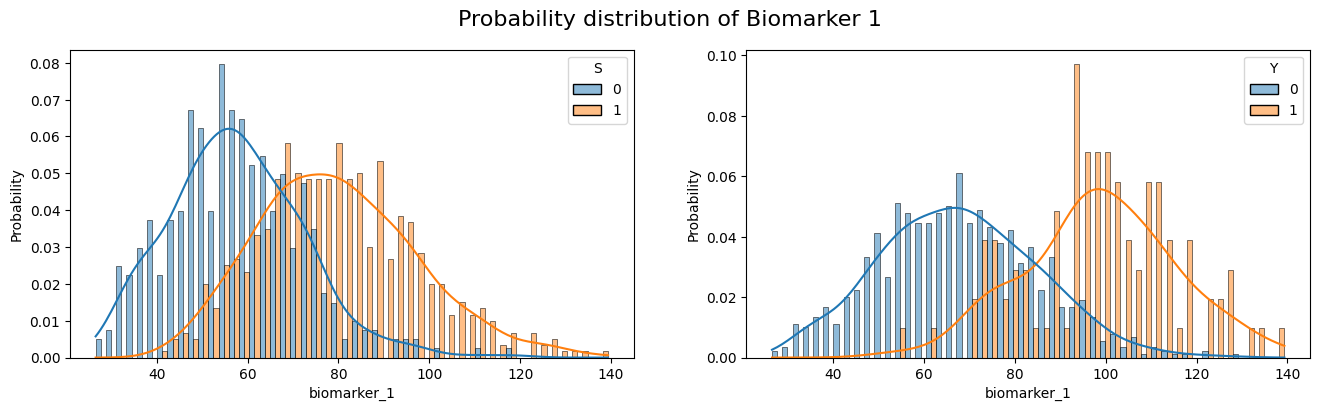

=== Class-balanced sampling ===


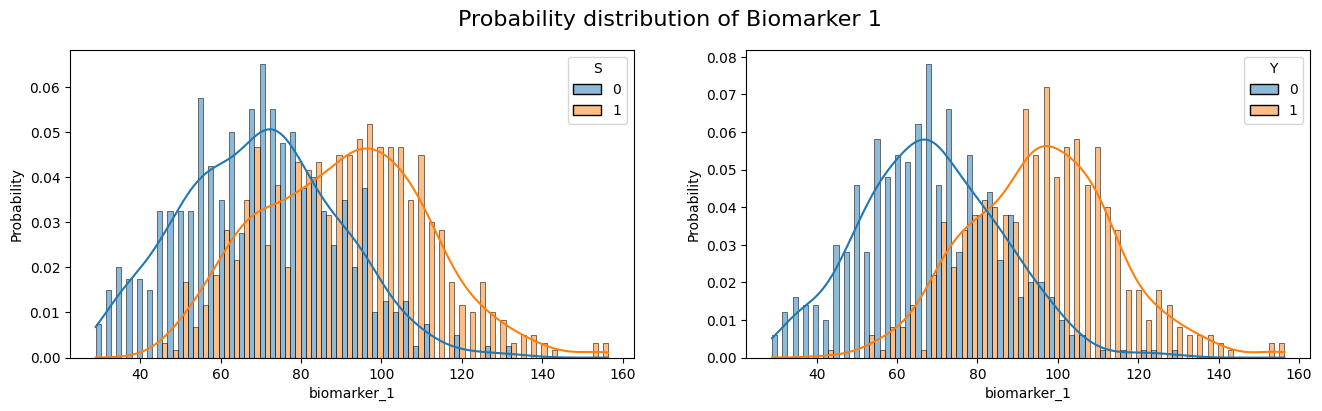

In [33]:
# Biomarker 1, influenced by S
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'biomarker_1', "Biomarker 1", "Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'biomarker_1', "Biomarker 1", "Y")

=== Proportion-preserving sampling ===


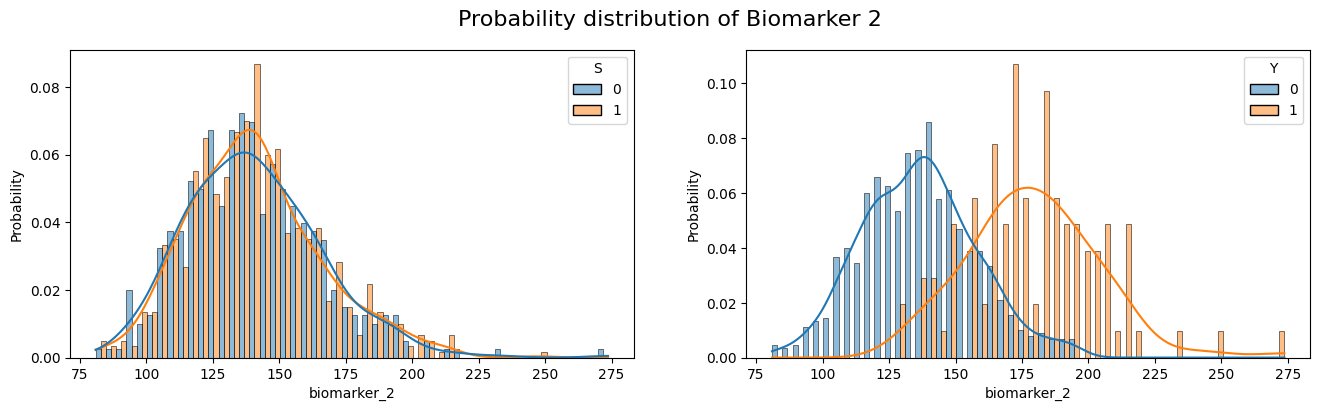

=== Class-balanced sampling ===


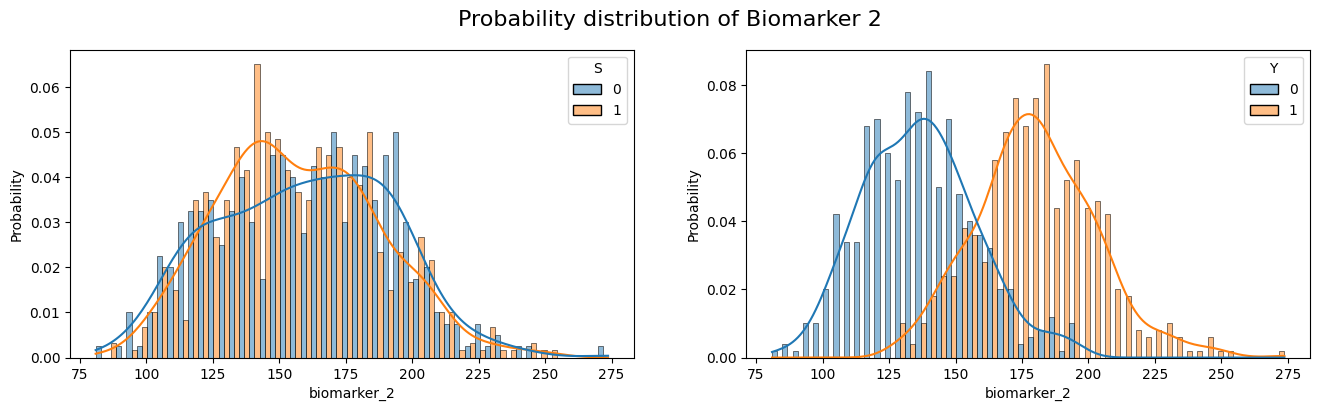

In [34]:
# Biomarker 2, independent from S
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'biomarker_2', "Biomarker 2", "Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'biomarker_2', "Biomarker 2", "Y")

# Biased datasets

## Apply bias to Desc path

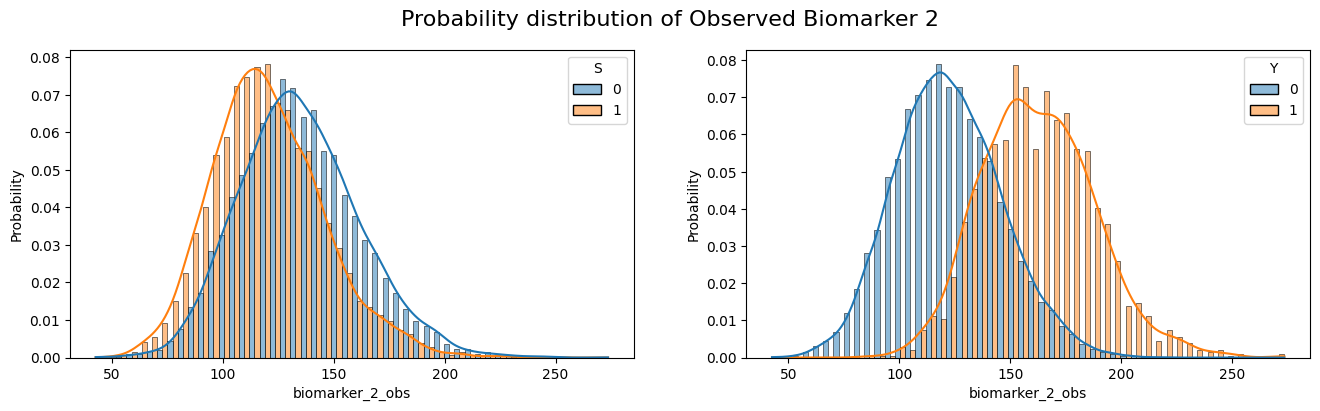

In [35]:
biased_df = apply_treatment_bias(unbiased_pop, "biomarker_2", s_target=0, bias_prob=0.7, b_mean_shift=-20, b_std_shift=3, seed=seed)

fig = plot_cont_feature(biased_df, "biomarker_2_obs", "Observed Biomarker 2", "Y")

## Sampling

In [36]:
# --- Unbiased sampling ---
# Preserving the population initial demographics
biased_train, biased_test = proportion_preserving_sampling(
  biased_df, 
  ['S', 'Y'], 
  n_train, n_test, seed)

# --- Class-balanced sampling ---
biased_classbal_train, biased_classbal_test = class_balanced_sampling(
  biased_df, 
  "Y",
  "S",
  n_train, n_test, seed)

In [37]:
print("=== Unbiased dataset, proportion-preserving sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(biased_train)}")
print(f"Prevalence in Training set: {biased_train['Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(biased_test)}")
print(f"Prevalence in Test set: {biased_test['Y'].mean():.2%}")

print("=== Unbiased dataset, class-balanced sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(biased_classbal_train)}")
print(f"Prevalence in Training set: {biased_classbal_train['Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(biased_classbal_test)}")
print(f"Prevalence in Test set: {biased_classbal_test['Y'].mean():.2%}")

=== Unbiased dataset, proportion-preserving sampling ===
Target Train size: 800 | Actual size: 802
Prevalence in Training set: 10.22%
Target Test size: 1000 | Actual size: 1002
Prevalence in Test set: 10.28%
=== Unbiased dataset, class-balanced sampling ===
Target Train size: 800 | Actual size: 800
Prevalence in Training set: 50.00%
Target Test size: 1000 | Actual size: 1000
Prevalence in Test set: 50.00%


## Test Distributions

======= PROPORTION PRESERVING SAMPLING =======
Biomarker 1


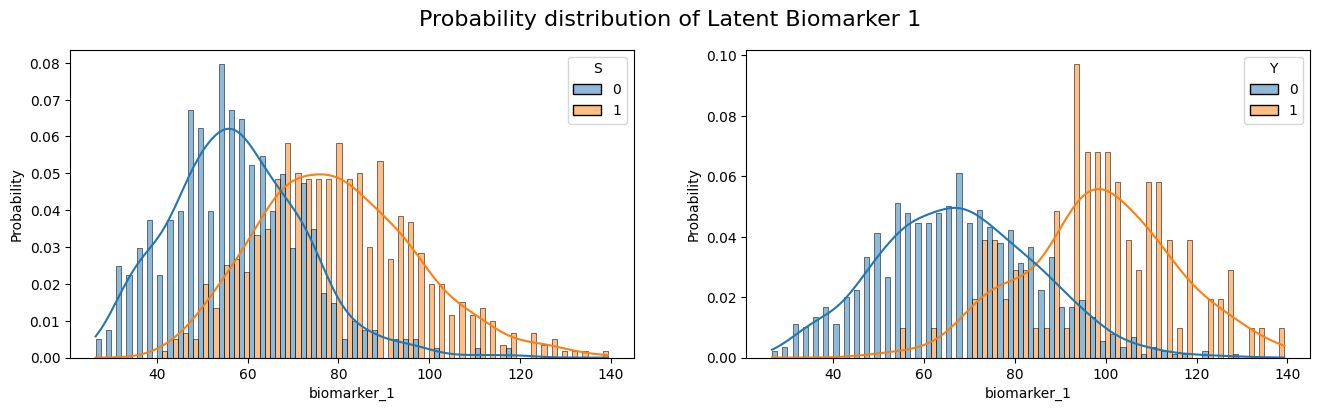

Unbiased biomarker 2


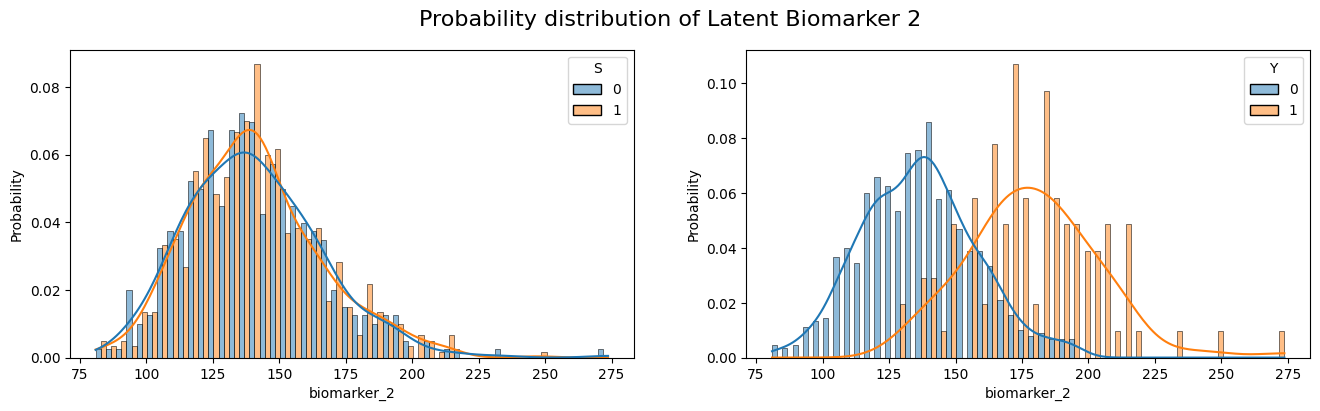

Biased biomarker 2


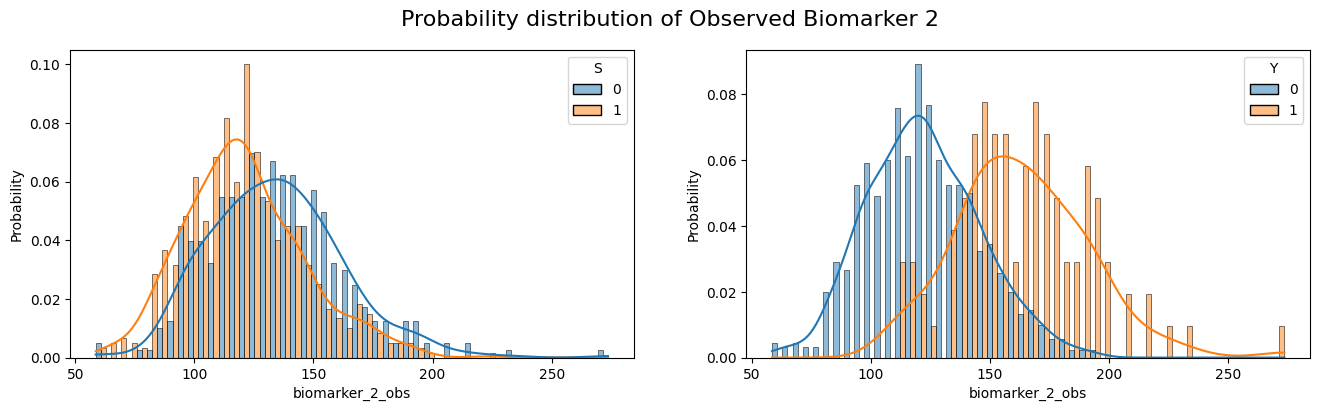

======= CLASS-BALANCED SAMPLING =======
Biomarker 1


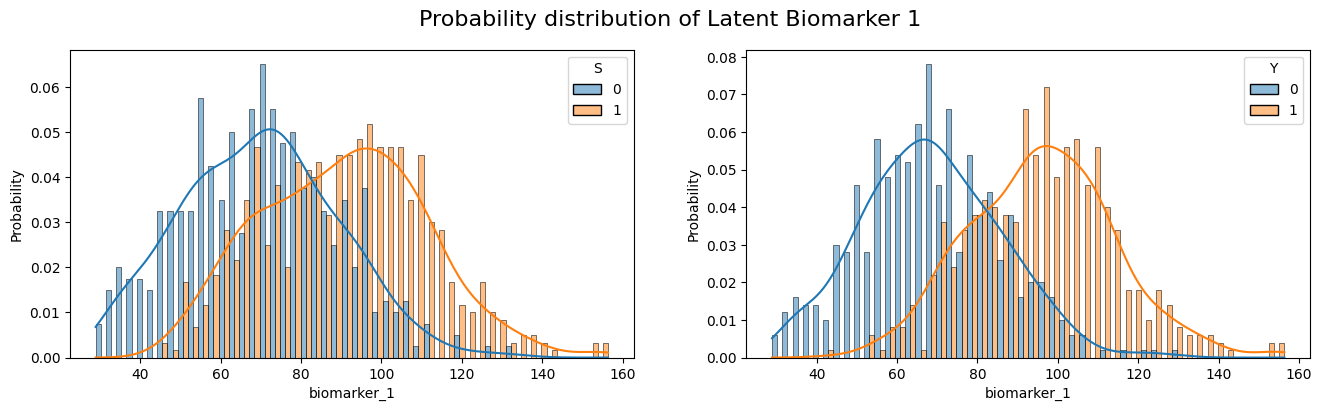

Unbiased biomarker 2


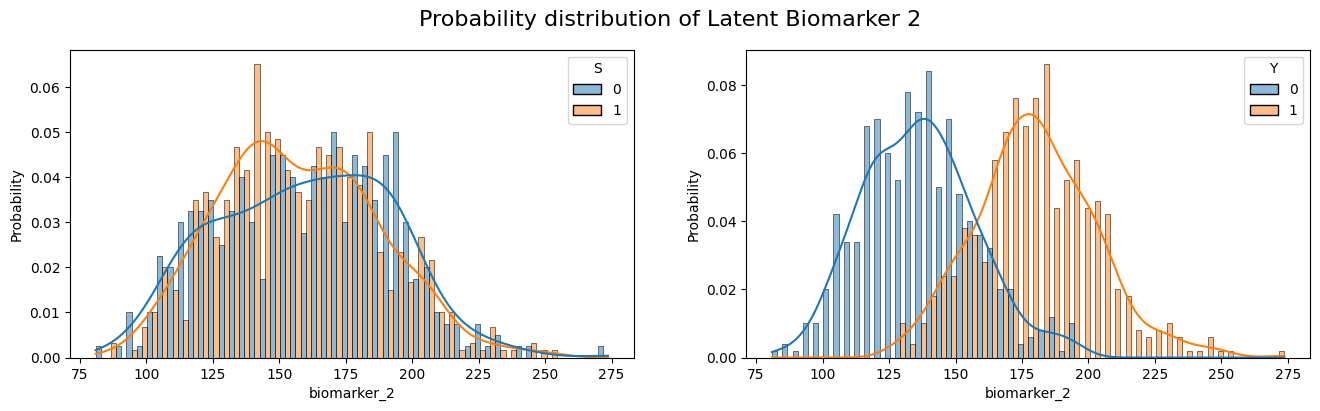

Biased biomarker 2


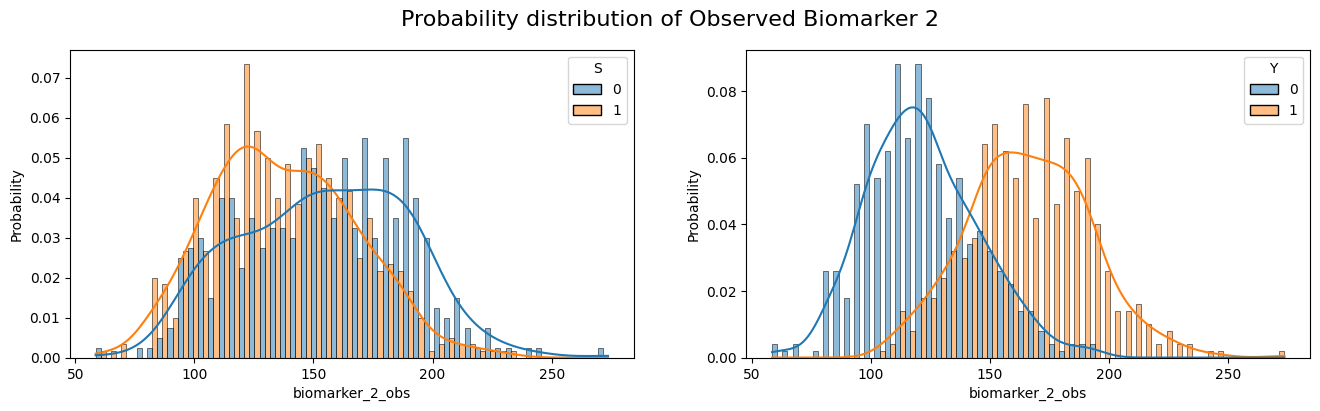

In [38]:
print(f'======= PROPORTION PRESERVING SAMPLING =======')
print(f'Biomarker 1')
fig = plot_cont_feature(biased_test, "biomarker_1", "Latent Biomarker 1", "Y")
print(f'Unbiased biomarker 2')
fig = plot_cont_feature(biased_test, "biomarker_2", "Latent Biomarker 2", "Y")
print(f'Biased biomarker 2')
fig = plot_cont_feature(biased_test, "biomarker_2_obs", "Observed Biomarker 2", "Y")
print(f'======= CLASS-BALANCED SAMPLING =======')
print(f'Biomarker 1')
fig = plot_cont_feature(biased_classbal_test, "biomarker_1", "Latent Biomarker 1", "Y")
print(f'Unbiased biomarker 2')
fig = plot_cont_feature(biased_classbal_test, "biomarker_2", "Latent Biomarker 2", "Y")
print(f'Biased biomarker 2')
fig = plot_cont_feature(biased_classbal_test, "biomarker_2_obs", "Observed Biomarker 2", "Y")

# Scaling

In [39]:
norm_variables = ['biomarker_2']
skewed_variables = ['biomarker_1']

unbiased_train_processed = scale_dataset(unbiased_train, norm_variables, skewed_variables)
unbiased_test_processed = scale_dataset(unbiased_test, norm_variables, skewed_variables)
unbiased_classbal_train_processed = scale_dataset(unbiased_bal_train, norm_variables, skewed_variables)
unbiased_classbal_test_processed = scale_dataset(unbiased_bal_test, norm_variables, skewed_variables)

unbiased_train_processed.to_csv(f'{data_dir}/simple_unbiased_test.csv', index=False)
unbiased_test_processed.to_csv(f'{data_dir}/simple_unbiased_train.csv', index=False)
unbiased_classbal_train_processed.to_csv(f'{data_dir}/simple_unbiased_classbal_train.csv', index=False)
unbiased_classbal_test_processed.to_csv(f'{data_dir}/simple_unbiased_classbal_test.csv', index=False)

In [40]:
norm_variables = []
skewed_variables = ['biomarker_1', 'biomarker_2']

biased_train_processed = scale_dataset(biased_train, norm_variables, skewed_variables)
biased_test_processed = scale_dataset(biased_test, norm_variables, skewed_variables)
biased_classbal_test_processed = scale_dataset(biased_classbal_train, norm_variables, skewed_variables)
biased_classbal_train_processed = scale_dataset(biased_classbal_test, norm_variables, skewed_variables)

biased_train_processed.to_csv(f'{data_dir}/simple_biased_test.csv', index=False)
biased_test_processed.to_csv(f'{data_dir}/simple_biased_train.csv', index=False)
biased_classbal_train_processed.to_csv(f'{data_dir}/simple_biased_classbal_train.csv', index=False)
biased_classbal_test_processed.to_csv(f'{data_dir}/simple_biased_classbal_test.csv', index=False)